In [31]:
from pytorch_grad_cam import GradCAM, AblationCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import torch
from torchvision.transforms import Compose, Normalize, ToTensor
from torchvision.models import resnet34
import os
import time
from PIL import Image
from torchvision import transforms
import torch.nn as nn

In [32]:
model = resnet34(pretrained=False)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [33]:
model.fc = nn.Linear(512, 3, bias=True)
model.load_state_dict(torch.load('model/mymodel.pth', map_location=torch.device('cpu')))

<All keys matched successfully>

In [34]:
image = Image.open('./imgdata/test.jpg')
transforms_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_img = transforms_test(image)
input_img.shape
input_img = input_img.unsqueeze(0)
input_img.shape

torch.Size([1, 3, 224, 224])

In [41]:
layer = model.layer4[2].conv2
layer1 = model.layer4[2].conv1
targets = [ClassifierOutputTarget(2)] # 본인이 찾고자하는 클래스의 카테고리

layer

Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)

In [42]:
cam = AblationCAM(model=model, target_layers=[layer, layer1])
cam.batch_size = 1

grayscale_cam = cam(input_tensor=input_img, targets=targets)
grayscale_cam = grayscale_cam[0, :]
grayscale_cam

100%|██████████| 512/512 [00:20<00:00, 25.18it/s]


array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.06919824, 0.06919824, 0.06919824, ..., 0.        , 0.        ,
        0.        ],
       [0.06919824, 0.06919824, 0.06919824, ..., 0.        , 0.        ,
        0.        ],
       [0.06919824, 0.06919824, 0.06919824, ..., 0.        , 0.        ,
        0.        ]], shape=(224, 224), dtype=float32)

In [43]:
grayscale_cam.max()

np.float32(0.9999998)

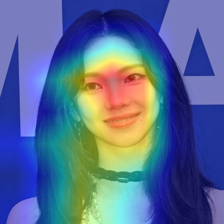

In [44]:
image = Image.open('./imgdata/test2.png')

image = image.resize((224, 224)).convert('RGB')

rgb_img = np.float32(image) / 255

result_grad_cam = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
display(Image.fromarray(result_grad_cam))